# Proteomics!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import sys
#csv.field_size_limit(sys.maxsize)

In [3]:
# Find where the data table begins
with open("../data/tarca-et-al-2021/GSE206454_family.soft", 'r') as f: # adjust for GPL28509_family (term + preterm) or GSE206454_family (term only)
    lines = f.readlines()

# Look for the start of tabular data (usually after "!platform_table_begin")
start_idx = None
for i, line in enumerate(lines):
    if "!platform_table_begin" in line.lower() or line.startswith("ID\t"):
        start_idx = i + 1  # Start after this line
        break

if start_idx:
    data = pd.read_csv("../data/tarca-et-al-2021/GSE206454_family.soft", 
                       sep="\t", 
                       skiprows=start_idx,
                       low_memory=False)
else:
    print("Could not find data table start.")

In [4]:
data.to_csv("../output/tarca_et_al_2021/GSE206454-term-only/full_data+metadata.csv", index = False)

# Restructure the somamer target metadata

In [5]:
# Create a metadata file
somamer_target_metadata = data[0:7597] # Use data[0:1130] for GPL28509 and data[0:7597] for GSE206454
# Remove the last row
somamer_target_metadata = somamer_target_metadata[:-1]
somamer_target_metadata

,ID,SeqId,SeqIdVersion,SomaId,TargetFullName,Target,UniProt,EntrezGeneID,EntrezGeneSymbol,Organism,Units,Type,SPOT_ID
0,CRYBB2.10000.28,10000-28,3.0,SL019233,Beta-crystallin B2,CRBB2,P43320,1415,CRYBB2,Human,RFU,Protein,SL019233
1,RAF1.10001.7,10001-7,3.0,SL002564,RAF proto-oncogene serine/threonine-protein ki...,c-Raf,P04049,5894,RAF1,Human,RFU,Protein,SL002564
2,ZNF41.10003.15,10003-15,3.0,SL019245,Zinc finger protein 41,ZNF41,P51814,7592,ZNF41,Human,RFU,Protein,SL019245
3,ELK1.10006.25,10006-25,3.0,SL019228,ETS domain-containing protein Elk-1,ELK1,P19419,2002,ELK1,Human,RFU,Protein,SL019228
4,GUCA1A.10008.43,10008-43,3.0,SL019234,Guanylyl cyclase-activating protein 1,GUC1A,P43080,2978,GUCA1A,Human,RFU,Protein,SL019234
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7591,ZNF264.9993.11,9993-11,3.0,SL019212,Zinc finger protein 264,ZN264,O43296,9422,ZNF264,Human,RFU,Protein,SL019212
7592,ATP4B.9994.217,9994-217,3.0,SL019217,Potassium-transporting ATPase subunit beta,ATP4B,P51164,496,ATP4B,Human,RFU,Protein,SL019217
7593,DUT.9995.6,9995-6,3.0,SL013164,Deoxyuridine 5'-triphosphate nucleotidohydrola...,DUT,P33316,1854,DUT,Human,RFU,Protein,SL013164
7594,UBXN4.9997.12,9997-12,3.0,SL019215,UBX domain-containing protein 4,UBXN4,Q92575,23190,UBXN4,Human,RFU,Protein,SL019215


In [6]:
# Save metadata to csv file
somamer_target_metadata.to_csv("../output/tarca_et_al_2021/GSE206454-term-only/somamer_target_metadata.csv", index = False)

# Build a sample metadata file

In [ ]:
# Term + Preterm study
metadata_dict = {
    "Accession": [],
    "Title": [],
    "Sample_type": [],
    "Sample_channel_count": [],
    "Tissue": [],
    "GA": [],
    "GA_delivery": [],
    "Group": [],
    "DiagnosisGA": [],
    "Individual": []
}

In [86]:
# Term only study
metadata_dict = {
    "Accession": [],
    "Title": [],
    "Sample_type": [],
    "GA": [],
    "Organism": [],
    "Individual": []
}

In [87]:
try:
    with open("../data/tarca-et-al-2021/GSE206454_family.soft", 'r') as f: # adjust the path based on the study
        lines = f.readlines()

        for i, line in enumerate(lines):
            if line.startswith("^SAMPLE"):
                parts = line.split()
                if len(parts) >= 3:
                    accession = parts[2]
                    metadata_dict["Accession"].append(accession)

            if line.startswith("!Sample_title"):
                parts = line.split()
                if len(parts) >= 3:
                    title = parts[2]
                    metadata_dict["Title"].append(title)

            if line.startswith("!Sample_type"):
                parts = line.split()
                if len(parts) >= 3:
                    sample_type = parts[2]
                    metadata_dict["Sample_type"].append(sample_type)

            # if line.startswith("!Sample_channel_count"):
            #    parts = line.split()
            #    if len(parts) >= 3:
            #        channel_count = parts[2]
            #        metadata_dict["Sample_channel_count"].append(channel_count)

            # if line.startswith("!Sample_source_name_ch1"):
            #    parts = line.split()
            #    if len(parts) >= 3:
            #        tissue = "maternal plasma"
            #        metadata_dict["Tissue"].append(tissue)

            if line.startswith("!Sample_characteristics_ch1 = gestational age:"):
                parts = line.split()
                if len(parts) >= 5:
                    ga = parts[4]
                    metadata_dict["GA"].append(ga)

            # if line.startswith("!Sample_characteristics_ch1 = gadelivery:"):
            #    parts = line.split()
            #    if len(parts) >= 4:
            #        gad = parts[3]
            #        metadata_dict["GA_delivery"].append(gad)

            # if line.startswith("!Sample_characteristics_ch1 = group:"):
            #     parts = line.split()
            #     if len(parts) >= 4:
            #         group = parts[3]
            #         metadata_dict["Group"].append(group)

            # if line.startswith("!Sample_characteristics_ch1 = diagnosisga:"):
            #     parts = line.split()
            #     if len(parts) >= 4:
            #         diagnosisga = parts[3]
            #         metadata_dict["DiagnosisGA"].append(diagnosisga)

            if line.startswith("!Sample_characteristics_ch1 = individual:"):
                parts = line.split()
                if len(parts) >= 4:
                    individual = parts[3]
                    metadata_dict["Individual"].append(individual)

            if line.startswith("!Sample_organism_ch1"):
                parts = line.split()
                if len(parts) >= 4:
                    organism = " ".join(parts[2:])
                    metadata_dict["Organism"].append(organism)

except Exception as e:
    print(f"An error occurred: {e}")

In [88]:
metadata_dict

{'Accession': ['GSM6254314',
  'GSM6254315',
  'GSM6254316',
  'GSM6254317',
  'GSM6254318',
  'GSM6254319',
  'GSM6254320',
  'GSM6254321',
  'GSM6254322',
  'GSM6254323',
  'GSM6254324',
  'GSM6254325',
  'GSM6254326',
  'GSM6254327',
  'GSM6254328',
  'GSM6254329',
  'GSM6254330',
  'GSM6254331',
  'GSM6254332',
  'GSM6254333',
  'GSM6254334',
  'GSM6254335',
  'GSM6254336',
  'GSM6254337',
  'GSM6254338',
  'GSM6254339',
  'GSM6254340',
  'GSM6254341',
  'GSM6254342',
  'GSM6254343',
  'GSM6254344',
  'GSM6254345',
  'GSM6254346',
  'GSM6254347',
  'GSM6254348',
  'GSM6254349',
  'GSM6254350',
  'GSM6254351',
  'GSM6254352',
  'GSM6254353',
  'GSM6254354',
  'GSM6254355',
  'GSM6254356',
  'GSM6254357',
  'GSM6254358',
  'GSM6254359',
  'GSM6254360',
  'GSM6254361',
  'GSM6254362',
  'GSM6254363',
  'GSM6254364',
  'GSM6254365',
  'GSM6254366',
  'GSM6254367',
  'GSM6254368',
  'GSM6254369',
  'GSM6254370',
  'GSM6254371',
  'GSM6254372',
  'GSM6254373',
  'GSM6254374',
  'GSM62543

In [89]:
sample_metadata = pd.DataFrame(metadata_dict)
sample_metadata

,Accession,Title,Sample_type,GA,Organism,Individual
0,GSM6254314,258633821569_7,protein,25.7,Homo sapiens,11293
1,GSM6254315,258633821572_7,protein,28.4,Homo sapiens,12820
2,GSM6254316,258633821573_6,protein,17.1,Homo sapiens,14054
3,GSM6254317,258633821570_3,protein,30,Homo sapiens,17825
4,GSM6254318,258633821569_3,protein,12.3,Homo sapiens,15468
...,...,...,...,...,...,...
514,GSM6254828,258633818631_4,protein,20.6,Homo sapiens,14977
515,GSM6254829,258633818628_4,protein,17.7,Homo sapiens,17509
516,GSM6254830,258633818627_4,protein,29.3,Homo sapiens,9900
517,GSM6254831,258633818634_3,protein,11.1,Homo sapiens,13592


In [90]:
for key, value in metadata_dict.items():
    print(f"{key}: {len(value)}")

Accession: 519
Title: 519
Sample_type: 519
GA: 519
Organism: 519
Individual: 519


In [ ]:
sample_metadata.to_csv("../output/tarca_et_al_2021/GSE206454-term-only/sample_metadata.csv", index = False)

In [ ]:
#sample_metadata.value_counts('Group')

Group
sPTD       124
Control     78
PPROM        8
Name: count, dtype: int64

# Build a data file

In [94]:
data_dict = {
    "Accession": [],
    "ID_REF": [],
    "Log2RFU": []
}

In [95]:
reading_table = False

try:
    with open("../data/tarca-et-al-2021/GSE206454_family.soft", 'r') as f:
        lines = f.readlines()

        for i, line in enumerate(lines):
            if line.startswith("^SAMPLE"):
                parts = line.split()
                if len(parts) >= 3:
                    accession = parts[2]
                    #data_dict["Accession"].append(accession)

            elif line.startswith("ID_REF") and "VALUE" in line:
                reading_table = True  
                continue
    
            elif reading_table:
                if line.startswith("!sample_table_end"):
                    reading_table = False  
                    continue
    
                parts = line.split()
                if len(parts) == 2:
                    id_ref, value = parts
                    data_dict["Accession"].append(accession)
                    data_dict["ID_REF"].append(id_ref)
                    data_dict["Log2RFU"].append(float(value))

except Exception as e:
    print(f"An error occurred: {e}")

In [96]:
data_dict

{'Accession': ['GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM6254314',
  'GSM62543

In [97]:
for key, value in data_dict.items():
    print(f"{key}: {len(value)}")

Accession: 3942324
ID_REF: 3942324
Log2RFU: 3942324


In [98]:
prot_data = pd.DataFrame(data_dict)
prot_data

,Accession,ID_REF,Log2RFU
0,GSM6254314,CRYBB2.10000.28,642.7
1,GSM6254314,RAF1.10001.7,314.7
2,GSM6254314,ZNF41.10003.15,166.3
3,GSM6254314,ELK1.10006.25,568.4
4,GSM6254314,GUCA1A.10008.43,401.4
...,...,...,...
3942319,GSM6254832,ZNF264.9993.11,1416.4
3942320,GSM6254832,ATP4B.9994.217,1593.0
3942321,GSM6254832,DUT.9995.6,7279.9
3942322,GSM6254832,UBXN4.9997.12,17454.6


In [18]:
prot_data.to_csv("../output/tarca_et_al_2021/GSE206454-term-only/data.csv", index = False)

In [19]:
data_targets_merged = pd.merge(prot_data, somamer_target_metadata, left_on='ID_REF', right_on='ID', how='inner')
data_targets_merged

,Accession,ID_REF,Log2RFU,ID,SeqId,SeqIdVersion,SomaId,TargetFullName,Target,UniProt,EntrezGeneID,EntrezGeneSymbol,Organism,Units,Type,SPOT_ID
0,GSM6254314,CRYBB2.10000.28,642.7,CRYBB2.10000.28,10000-28,3.0,SL019233,Beta-crystallin B2,CRBB2,P43320,1415,CRYBB2,Human,RFU,Protein,SL019233
1,GSM6254314,RAF1.10001.7,314.7,RAF1.10001.7,10001-7,3.0,SL002564,RAF proto-oncogene serine/threonine-protein ki...,c-Raf,P04049,5894,RAF1,Human,RFU,Protein,SL002564
2,GSM6254314,ZNF41.10003.15,166.3,ZNF41.10003.15,10003-15,3.0,SL019245,Zinc finger protein 41,ZNF41,P51814,7592,ZNF41,Human,RFU,Protein,SL019245
3,GSM6254314,ELK1.10006.25,568.4,ELK1.10006.25,10006-25,3.0,SL019228,ETS domain-containing protein Elk-1,ELK1,P19419,2002,ELK1,Human,RFU,Protein,SL019228
4,GSM6254314,GUCA1A.10008.43,401.4,GUCA1A.10008.43,10008-43,3.0,SL019234,Guanylyl cyclase-activating protein 1,GUC1A,P43080,2978,GUCA1A,Human,RFU,Protein,SL019234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3942319,GSM6254832,ZNF264.9993.11,1416.4,ZNF264.9993.11,9993-11,3.0,SL019212,Zinc finger protein 264,ZN264,O43296,9422,ZNF264,Human,RFU,Protein,SL019212
3942320,GSM6254832,ATP4B.9994.217,1593.0,ATP4B.9994.217,9994-217,3.0,SL019217,Potassium-transporting ATPase subunit beta,ATP4B,P51164,496,ATP4B,Human,RFU,Protein,SL019217
3942321,GSM6254832,DUT.9995.6,7279.9,DUT.9995.6,9995-6,3.0,SL013164,Deoxyuridine 5'-triphosphate nucleotidohydrola...,DUT,P33316,1854,DUT,Human,RFU,Protein,SL013164
3942322,GSM6254832,UBXN4.9997.12,17454.6,UBXN4.9997.12,9997-12,3.0,SL019215,UBX domain-containing protein 4,UBXN4,Q92575,23190,UBXN4,Human,RFU,Protein,SL019215


In [29]:
merged_controls = pd.merge(data_targets_merged, sample_metadata, on='Accession', how='inner')
merged_controls

,Accession,ID_REF,Log2RFU,ID,SeqId,SeqIdVersion,SomaId,TargetFullName,Target,UniProt,EntrezGeneID,EntrezGeneSymbol,Organism_x,Units,Type,SPOT_ID,Title,Sample_type,GA,Organism_y
0,GSM6254314,CRYBB2.10000.28,642.7,CRYBB2.10000.28,10000-28,3.0,SL019233,Beta-crystallin B2,CRBB2,P43320,1415,CRYBB2,Human,RFU,Protein,SL019233,258633821569_7,protein,25.7,Homo sapiens
1,GSM6254314,RAF1.10001.7,314.7,RAF1.10001.7,10001-7,3.0,SL002564,RAF proto-oncogene serine/threonine-protein ki...,c-Raf,P04049,5894,RAF1,Human,RFU,Protein,SL002564,258633821569_7,protein,25.7,Homo sapiens
2,GSM6254314,ZNF41.10003.15,166.3,ZNF41.10003.15,10003-15,3.0,SL019245,Zinc finger protein 41,ZNF41,P51814,7592,ZNF41,Human,RFU,Protein,SL019245,258633821569_7,protein,25.7,Homo sapiens
3,GSM6254314,ELK1.10006.25,568.4,ELK1.10006.25,10006-25,3.0,SL019228,ETS domain-containing protein Elk-1,ELK1,P19419,2002,ELK1,Human,RFU,Protein,SL019228,258633821569_7,protein,25.7,Homo sapiens
4,GSM6254314,GUCA1A.10008.43,401.4,GUCA1A.10008.43,10008-43,3.0,SL019234,Guanylyl cyclase-activating protein 1,GUC1A,P43080,2978,GUCA1A,Human,RFU,Protein,SL019234,258633821569_7,protein,25.7,Homo sapiens
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3806860,GSM6254832,ZNF264.9993.11,1416.4,ZNF264.9993.11,9993-11,3.0,SL019212,Zinc finger protein 264,ZN264,O43296,9422,ZNF264,Human,RFU,Protein,SL019212,258633818632_3,protein,37.9,Homo sapiens
3806861,GSM6254832,ATP4B.9994.217,1593.0,ATP4B.9994.217,9994-217,3.0,SL019217,Potassium-transporting ATPase subunit beta,ATP4B,P51164,496,ATP4B,Human,RFU,Protein,SL019217,258633818632_3,protein,37.9,Homo sapiens
3806862,GSM6254832,DUT.9995.6,7279.9,DUT.9995.6,9995-6,3.0,SL013164,Deoxyuridine 5'-triphosphate nucleotidohydrola...,DUT,P33316,1854,DUT,Human,RFU,Protein,SL013164,258633818632_3,protein,37.9,Homo sapiens
3806863,GSM6254832,UBXN4.9997.12,17454.6,UBXN4.9997.12,9997-12,3.0,SL019215,UBX domain-containing protein 4,UBXN4,Q92575,23190,UBXN4,Human,RFU,Protein,SL019215,258633818632_3,protein,37.9,Homo sapiens


In [ ]:
# Remove all non-human samples
#data_targets_merged.value_counts('Organism')
#data_targets_merged = data_targets_merged[data_targets_merged['Organism'] == 'Human']
#data_targets_merged.value_counts('Organism')

#merged_controls.value_counts('Organism_x')
#merged_controls = merged_controls[merged_controls['Organism_x'] == 'Human']
#merged_controls.value_counts('Organism_x')
#merged_controls.to_csv("../output/tarca_et_al_2021/GSE206454-term-only/full_data_merged.csv", index = False)

Organism
Human    3806865
Name: count, dtype: int64

In [30]:
merged_controls.value_counts('Organism_x')
#merged_controls = merged_controls[merged_controls['Organism_x'] == 'Human']
#merged_controls.value_counts('Organism_x')

Organism_x
Human    3806865
Name: count, dtype: int64

In [36]:
# Set the working directory
import os
#os.chdir('code/')

# Verify the change
print("Current Working Directory:", os.getcwd())

Current Working Directory: c:\Users\doram\Desktop\Masters\RP-2\code


# Data analysis

### Preprocess the data

In [3]:
preterm_data = pd.read_csv("../output/tarca_et_al_2021/GSE150167-term+preterm/full_data_merged.csv")
preterm_data

,Accession,ID_REF,Log2RFU,ID,PT_LIST,SeqId,Target,TargetFullName,UniProt,ENTREZ_GENE_ID_LIST,...,SPOT_ID,Title,Sample_type,Sample_channel_count,Tissue,GA,GA_delivery,Group,DiagnosisGA,Individual
0,GSM4525301,SL000318,12.579057,SL000318,"P0C0L4,P0C0L5",2182-54_1,C4b,Complement C4b,P0C0L4 P0C0L5,"720,721",...,SL000318,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273
1,GSM4525301,SL002662,10.688600,SL002662,P03951,2190-55_1,Coagulation Factor XI,Coagulation Factor XI,P03951,2160,...,SL002662,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273
2,GSM4525301,SL003168,10.516685,SL003168,Q9Y4X3,2192-63_10,CTACK,C-C motif chemokine 27,Q9Y4X3,10850,...,SL003168,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273
3,GSM4525301,SL000403,15.616368,SL000403,P39060,2201-17_6,Endostatin,Endostatin,P39060,80781,...,SL000403,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273
4,GSM4525301,SL000591,8.400026,SL000591,P01033,2211-9_6,TIMP-1,Metalloproteinase inhibitor 1,P01033,7076,...,SL000591,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236245,GSM4525510,SL010516,13.875874,SL010516,P12931,5488-74_3,SRCN1,Proto-oncogene tyrosine-protein kinase Src,P12931,6714,...,SL010516,s469,protein,1,maternal plasma,29.7,33.3,sPTD,33.3,9754
236246,GSM4525510,SL010250,13.167904,SL010250,P31948,5489-18_3,Stress-induced-phosphoprotein 1,Stress-induced-phosphoprotein 1,P31948,10963,...,SL010250,s469,protein,1,maternal plasma,29.7,33.3,sPTD,33.3,9754
236247,GSM4525510,SL010384,11.996968,SL010384,Q08629,5490-53_3,Testican-1,Testican-1,Q08629,6695,...,SL010384,s469,protein,1,maternal plasma,29.7,33.3,sPTD,33.3,9754
236248,GSM4525510,SL010471,9.221829,SL010471,Q92563,5491-12_3,Testican-2,Testican-2,Q92563,9806,...,SL010471,s469,protein,1,maternal plasma,29.7,33.3,sPTD,33.3,9754


In [4]:
preterm_data['GEO_accession'] = 'GSE150167'
preterm_data = preterm_data.rename(columns={'ENTREZ_GENE_ID_LIST': 'EntrezGeneID'})
preterm_data

,Accession,ID_REF,Log2RFU,ID,PT_LIST,SeqId,Target,TargetFullName,UniProt,EntrezGeneID,...,Title,Sample_type,Sample_channel_count,Tissue,GA,GA_delivery,Group,DiagnosisGA,Individual,GEO_accession
0,GSM4525301,SL000318,12.579057,SL000318,"P0C0L4,P0C0L5",2182-54_1,C4b,Complement C4b,P0C0L4 P0C0L5,"720,721",...,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273,GSE150167
1,GSM4525301,SL002662,10.688600,SL002662,P03951,2190-55_1,Coagulation Factor XI,Coagulation Factor XI,P03951,2160,...,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273,GSE150167
2,GSM4525301,SL003168,10.516685,SL003168,Q9Y4X3,2192-63_10,CTACK,C-C motif chemokine 27,Q9Y4X3,10850,...,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273,GSE150167
3,GSM4525301,SL000403,15.616368,SL000403,P39060,2201-17_6,Endostatin,Endostatin,P39060,80781,...,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273,GSE150167
4,GSM4525301,SL000591,8.400026,SL000591,P01033,2211-9_6,TIMP-1,Metalloproteinase inhibitor 1,P01033,7076,...,s132,protein,1,maternal plasma,16.9,40.1,Control,NaN,10273,GSE150167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236245,GSM4525510,SL010516,13.875874,SL010516,P12931,5488-74_3,SRCN1,Proto-oncogene tyrosine-protein kinase Src,P12931,6714,...,s469,protein,1,maternal plasma,29.7,33.3,sPTD,33.3,9754,GSE150167
236246,GSM4525510,SL010250,13.167904,SL010250,P31948,5489-18_3,Stress-induced-phosphoprotein 1,Stress-induced-phosphoprotein 1,P31948,10963,...,s469,protein,1,maternal plasma,29.7,33.3,sPTD,33.3,9754,GSE150167
236247,GSM4525510,SL010384,11.996968,SL010384,Q08629,5490-53_3,Testican-1,Testican-1,Q08629,6695,...,s469,protein,1,maternal plasma,29.7,33.3,sPTD,33.3,9754,GSE150167
236248,GSM4525510,SL010471,9.221829,SL010471,Q92563,5491-12_3,Testican-2,Testican-2,Q92563,9806,...,s469,protein,1,maternal plasma,29.7,33.3,sPTD,33.3,9754,GSE150167


In [5]:
preterm_data = preterm_data.drop(['ID', 'PT_LIST', 'Sample_channel_count', 'Tissue', 'DiagnosisGA', 'SPOT_ID'], axis = 1)
preterm_data

,Accession,ID_REF,Log2RFU,SeqId,Target,TargetFullName,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,GA_delivery,Group,Individual,GEO_accession
0,GSM4525301,SL000318,12.579057,2182-54_1,C4b,Complement C4b,P0C0L4 P0C0L5,"720,721",C4A C4B,s132,protein,16.9,40.1,Control,10273,GSE150167
1,GSM4525301,SL002662,10.688600,2190-55_1,Coagulation Factor XI,Coagulation Factor XI,P03951,2160,F11,s132,protein,16.9,40.1,Control,10273,GSE150167
2,GSM4525301,SL003168,10.516685,2192-63_10,CTACK,C-C motif chemokine 27,Q9Y4X3,10850,CCL27,s132,protein,16.9,40.1,Control,10273,GSE150167
3,GSM4525301,SL000403,15.616368,2201-17_6,Endostatin,Endostatin,P39060,80781,COL18A1,s132,protein,16.9,40.1,Control,10273,GSE150167
4,GSM4525301,SL000591,8.400026,2211-9_6,TIMP-1,Metalloproteinase inhibitor 1,P01033,7076,TIMP1,s132,protein,16.9,40.1,Control,10273,GSE150167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236245,GSM4525510,SL010516,13.875874,5488-74_3,SRCN1,Proto-oncogene tyrosine-protein kinase Src,P12931,6714,SRC,s469,protein,29.7,33.3,sPTD,9754,GSE150167
236246,GSM4525510,SL010250,13.167904,5489-18_3,Stress-induced-phosphoprotein 1,Stress-induced-phosphoprotein 1,P31948,10963,STIP1,s469,protein,29.7,33.3,sPTD,9754,GSE150167
236247,GSM4525510,SL010384,11.996968,5490-53_3,Testican-1,Testican-1,Q08629,6695,SPOCK1,s469,protein,29.7,33.3,sPTD,9754,GSE150167
236248,GSM4525510,SL010471,9.221829,5491-12_3,Testican-2,Testican-2,Q92563,9806,SPOCK2,s469,protein,29.7,33.3,sPTD,9754,GSE150167


In [6]:
term_data = pd.read_csv("../output/tarca_et_al_2021/GSE206454-term-only/full_data_merged.csv")
term_data

,Accession,ID_REF,Log2RFU,ID,SeqId,SeqIdVersion,SomaId,TargetFullName,Target,UniProt,...,EntrezGeneSymbol,Organism_x,Units,Type,SPOT_ID,Title,Sample_type,GA,Organism_y,Individual
0,GSM6254314,CRYBB2.10000.28,642.7,CRYBB2.10000.28,10000-28,3.0,SL019233,Beta-crystallin B2,CRBB2,P43320,...,CRYBB2,Human,RFU,Protein,SL019233,258633821569_7,protein,25.7,Homo sapiens,11293
1,GSM6254314,RAF1.10001.7,314.7,RAF1.10001.7,10001-7,3.0,SL002564,RAF proto-oncogene serine/threonine-protein ki...,c-Raf,P04049,...,RAF1,Human,RFU,Protein,SL002564,258633821569_7,protein,25.7,Homo sapiens,11293
2,GSM6254314,ZNF41.10003.15,166.3,ZNF41.10003.15,10003-15,3.0,SL019245,Zinc finger protein 41,ZNF41,P51814,...,ZNF41,Human,RFU,Protein,SL019245,258633821569_7,protein,25.7,Homo sapiens,11293
3,GSM6254314,ELK1.10006.25,568.4,ELK1.10006.25,10006-25,3.0,SL019228,ETS domain-containing protein Elk-1,ELK1,P19419,...,ELK1,Human,RFU,Protein,SL019228,258633821569_7,protein,25.7,Homo sapiens,11293
4,GSM6254314,GUCA1A.10008.43,401.4,GUCA1A.10008.43,10008-43,3.0,SL019234,Guanylyl cyclase-activating protein 1,GUC1A,P43080,...,GUCA1A,Human,RFU,Protein,SL019234,258633821569_7,protein,25.7,Homo sapiens,11293
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3806860,GSM6254832,ZNF264.9993.11,1416.4,ZNF264.9993.11,9993-11,3.0,SL019212,Zinc finger protein 264,ZN264,O43296,...,ZNF264,Human,RFU,Protein,SL019212,258633818632_3,protein,37.9,Homo sapiens,13592
3806861,GSM6254832,ATP4B.9994.217,1593.0,ATP4B.9994.217,9994-217,3.0,SL019217,Potassium-transporting ATPase subunit beta,ATP4B,P51164,...,ATP4B,Human,RFU,Protein,SL019217,258633818632_3,protein,37.9,Homo sapiens,13592
3806862,GSM6254832,DUT.9995.6,7279.9,DUT.9995.6,9995-6,3.0,SL013164,Deoxyuridine 5'-triphosphate nucleotidohydrola...,DUT,P33316,...,DUT,Human,RFU,Protein,SL013164,258633818632_3,protein,37.9,Homo sapiens,13592
3806863,GSM6254832,UBXN4.9997.12,17454.6,UBXN4.9997.12,9997-12,3.0,SL019215,UBX domain-containing protein 4,UBXN4,Q92575,...,UBXN4,Human,RFU,Protein,SL019215,258633818632_3,protein,37.9,Homo sapiens,13592


In [7]:
# Add the Group column labelling all samples as controls (term)
term_data['Group'] = 'Control'
term_data['GEO_accession'] = 'GSE206454'
term_data

,Accession,ID_REF,Log2RFU,ID,SeqId,SeqIdVersion,SomaId,TargetFullName,Target,UniProt,...,Units,Type,SPOT_ID,Title,Sample_type,GA,Organism_y,Individual,Group,GEO_accession
0,GSM6254314,CRYBB2.10000.28,642.7,CRYBB2.10000.28,10000-28,3.0,SL019233,Beta-crystallin B2,CRBB2,P43320,...,RFU,Protein,SL019233,258633821569_7,protein,25.7,Homo sapiens,11293,Control,GSE206454
1,GSM6254314,RAF1.10001.7,314.7,RAF1.10001.7,10001-7,3.0,SL002564,RAF proto-oncogene serine/threonine-protein ki...,c-Raf,P04049,...,RFU,Protein,SL002564,258633821569_7,protein,25.7,Homo sapiens,11293,Control,GSE206454
2,GSM6254314,ZNF41.10003.15,166.3,ZNF41.10003.15,10003-15,3.0,SL019245,Zinc finger protein 41,ZNF41,P51814,...,RFU,Protein,SL019245,258633821569_7,protein,25.7,Homo sapiens,11293,Control,GSE206454
3,GSM6254314,ELK1.10006.25,568.4,ELK1.10006.25,10006-25,3.0,SL019228,ETS domain-containing protein Elk-1,ELK1,P19419,...,RFU,Protein,SL019228,258633821569_7,protein,25.7,Homo sapiens,11293,Control,GSE206454
4,GSM6254314,GUCA1A.10008.43,401.4,GUCA1A.10008.43,10008-43,3.0,SL019234,Guanylyl cyclase-activating protein 1,GUC1A,P43080,...,RFU,Protein,SL019234,258633821569_7,protein,25.7,Homo sapiens,11293,Control,GSE206454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3806860,GSM6254832,ZNF264.9993.11,1416.4,ZNF264.9993.11,9993-11,3.0,SL019212,Zinc finger protein 264,ZN264,O43296,...,RFU,Protein,SL019212,258633818632_3,protein,37.9,Homo sapiens,13592,Control,GSE206454
3806861,GSM6254832,ATP4B.9994.217,1593.0,ATP4B.9994.217,9994-217,3.0,SL019217,Potassium-transporting ATPase subunit beta,ATP4B,P51164,...,RFU,Protein,SL019217,258633818632_3,protein,37.9,Homo sapiens,13592,Control,GSE206454
3806862,GSM6254832,DUT.9995.6,7279.9,DUT.9995.6,9995-6,3.0,SL013164,Deoxyuridine 5'-triphosphate nucleotidohydrola...,DUT,P33316,...,RFU,Protein,SL013164,258633818632_3,protein,37.9,Homo sapiens,13592,Control,GSE206454
3806863,GSM6254832,UBXN4.9997.12,17454.6,UBXN4.9997.12,9997-12,3.0,SL019215,UBX domain-containing protein 4,UBXN4,Q92575,...,RFU,Protein,SL019215,258633818632_3,protein,37.9,Homo sapiens,13592,Control,GSE206454


In [8]:
# Are all the values the same and coming from human samples?
#term_data.value_counts('Organism_x')
#term_data.value_counts('Organism_y')

# Yes, they are. Remove both columns, along with other redundant columns, in that case. 
term_data = term_data.drop(['Organism_x', 'Organism_y', 'ID', 'ID_REF', 'SPOT_ID', 'SeqIdVersion', 'Type', 'Units'], axis = 1) # ID = ID_REF, SPOT_ID = SomaId, and SomaId is an actual ID_REF.

# Change the name of SomaId column to ID_REF
term_data = term_data.rename(columns={'SomaId': 'ID_REF'})

# Add GA_delivery column and fill with NaNs
term_data['GA_delivery'] = 'NaN'
term_data

,Accession,Log2RFU,SeqId,ID_REF,TargetFullName,Target,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,Individual,Group,GEO_accession,GA_delivery
0,GSM6254314,642.7,10000-28,SL019233,Beta-crystallin B2,CRBB2,P43320,1415,CRYBB2,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
1,GSM6254314,314.7,10001-7,SL002564,RAF proto-oncogene serine/threonine-protein ki...,c-Raf,P04049,5894,RAF1,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
2,GSM6254314,166.3,10003-15,SL019245,Zinc finger protein 41,ZNF41,P51814,7592,ZNF41,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
3,GSM6254314,568.4,10006-25,SL019228,ETS domain-containing protein Elk-1,ELK1,P19419,2002,ELK1,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
4,GSM6254314,401.4,10008-43,SL019234,Guanylyl cyclase-activating protein 1,GUC1A,P43080,2978,GUCA1A,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3806860,GSM6254832,1416.4,9993-11,SL019212,Zinc finger protein 264,ZN264,O43296,9422,ZNF264,258633818632_3,protein,37.9,13592,Control,GSE206454,NaN
3806861,GSM6254832,1593.0,9994-217,SL019217,Potassium-transporting ATPase subunit beta,ATP4B,P51164,496,ATP4B,258633818632_3,protein,37.9,13592,Control,GSE206454,NaN
3806862,GSM6254832,7279.9,9995-6,SL013164,Deoxyuridine 5'-triphosphate nucleotidohydrola...,DUT,P33316,1854,DUT,258633818632_3,protein,37.9,13592,Control,GSE206454,NaN
3806863,GSM6254832,17454.6,9997-12,SL019215,UBX domain-containing protein 4,UBXN4,Q92575,23190,UBXN4,258633818632_3,protein,37.9,13592,Control,GSE206454,NaN


In [9]:
preterm_data

,Accession,ID_REF,Log2RFU,SeqId,Target,TargetFullName,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,GA_delivery,Group,Individual,GEO_accession
0,GSM4525301,SL000318,12.579057,2182-54_1,C4b,Complement C4b,P0C0L4 P0C0L5,"720,721",C4A C4B,s132,protein,16.9,40.1,Control,10273,GSE150167
1,GSM4525301,SL002662,10.688600,2190-55_1,Coagulation Factor XI,Coagulation Factor XI,P03951,2160,F11,s132,protein,16.9,40.1,Control,10273,GSE150167
2,GSM4525301,SL003168,10.516685,2192-63_10,CTACK,C-C motif chemokine 27,Q9Y4X3,10850,CCL27,s132,protein,16.9,40.1,Control,10273,GSE150167
3,GSM4525301,SL000403,15.616368,2201-17_6,Endostatin,Endostatin,P39060,80781,COL18A1,s132,protein,16.9,40.1,Control,10273,GSE150167
4,GSM4525301,SL000591,8.400026,2211-9_6,TIMP-1,Metalloproteinase inhibitor 1,P01033,7076,TIMP1,s132,protein,16.9,40.1,Control,10273,GSE150167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236245,GSM4525510,SL010516,13.875874,5488-74_3,SRCN1,Proto-oncogene tyrosine-protein kinase Src,P12931,6714,SRC,s469,protein,29.7,33.3,sPTD,9754,GSE150167
236246,GSM4525510,SL010250,13.167904,5489-18_3,Stress-induced-phosphoprotein 1,Stress-induced-phosphoprotein 1,P31948,10963,STIP1,s469,protein,29.7,33.3,sPTD,9754,GSE150167
236247,GSM4525510,SL010384,11.996968,5490-53_3,Testican-1,Testican-1,Q08629,6695,SPOCK1,s469,protein,29.7,33.3,sPTD,9754,GSE150167
236248,GSM4525510,SL010471,9.221829,5491-12_3,Testican-2,Testican-2,Q92563,9806,SPOCK2,s469,protein,29.7,33.3,sPTD,9754,GSE150167


In [107]:
term_data['EntrezGeneSymbol'].isin(preterm_data['EntrezGeneSymbol']).value_counts()

EntrezGeneSymbol
False    3053277
True      753588
Name: count, dtype: int64

In [10]:
filtered_term_data = term_data[term_data['EntrezGeneSymbol'].isin(preterm_data['EntrezGeneSymbol'])]
filtered_term_data

,Accession,Log2RFU,SeqId,ID_REF,TargetFullName,Target,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,Individual,Group,GEO_accession,GA_delivery
67,GSM6254314,47148.9,10382-1,SL006803,Angiopoietin-related protein 3,ANGL3,Q9Y5C1,27329,ANGPTL3,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
69,GSM6254314,1503.3,10391-1,SL006803,Angiopoietin-related protein 3,ANGL3,Q9Y5C1,27329,ANGPTL3,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
93,GSM6254314,402.8,10457-3,SL004861,Interleukin-18 receptor accessory protein,IL-18 Rb,O95256,8807,IL18RAP,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
94,GSM6254314,2720.4,10460-1,SL006029,Chitotriosidase-1,Chitotriosidase-1,Q13231,1118,CHIT1,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
99,GSM6254314,1446.9,10472-53,SL004145,Tumor necrosis factor receptor superfamily mem...,HVEM,Q92956,8764,TNFRSF14,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3806722,GSM6254832,2406.6,9760-13,SL004716,Mitogen-activated protein kinase 9,JNK2,P45984,5601,MAPK9,258633818632_3,protein,37.9,13592,Control,GSE206454,NaN
3806737,GSM6254832,605.6,9787-23,SL007471,Collectin-12,COLEC12,Q5KU26,81035,COLEC12,258633818632_3,protein,37.9,13592,Control,GSE206454,NaN
3806769,GSM6254832,479.0,9845-33,SL008933,Protein DJ-1,PARK7,Q99497,11315,PARK7,258633818632_3,protein,37.9,13592,Control,GSE206454,NaN
3806819,GSM6254832,429.0,9925-56,SL005222,Scavenger receptor class F member 2,SREC-II,Q96GP6,91179,SCARF2,258633818632_3,protein,37.9,13592,Control,GSE206454,NaN


In [109]:
filtered_term_data[filtered_term_data['Accession'] == 'GSM6254314']

,Accession,Log2RFU,SeqId,ID_REF,TargetFullName,Target,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,Individual,Group,GEO_accession,GA_delivery
67,GSM6254314,47148.9,10382-1,SL006803,Angiopoietin-related protein 3,ANGL3,Q9Y5C1,27329,ANGPTL3,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
69,GSM6254314,1503.3,10391-1,SL006803,Angiopoietin-related protein 3,ANGL3,Q9Y5C1,27329,ANGPTL3,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
93,GSM6254314,402.8,10457-3,SL004861,Interleukin-18 receptor accessory protein,IL-18 Rb,O95256,8807,IL18RAP,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
94,GSM6254314,2720.4,10460-1,SL006029,Chitotriosidase-1,Chitotriosidase-1,Q13231,1118,CHIT1,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
99,GSM6254314,1446.9,10472-53,SL004145,Tumor necrosis factor receptor superfamily mem...,HVEM,Q92956,8764,TNFRSF14,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7192,GSM6254314,3514.8,9760-13,SL004716,Mitogen-activated protein kinase 9,JNK2,P45984,5601,MAPK9,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
7207,GSM6254314,538.1,9787-23,SL007471,Collectin-12,COLEC12,Q5KU26,81035,COLEC12,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
7239,GSM6254314,372.1,9845-33,SL008933,Protein DJ-1,PARK7,Q99497,11315,PARK7,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN
7289,GSM6254314,397.1,9925-56,SL005222,Scavenger receptor class F member 2,SREC-II,Q96GP6,91179,SCARF2,258633821569_7,protein,25.7,11293,Control,GSE206454,NaN


In [14]:
# Concatenate the two datasets
merged_data = pd.concat([preterm_data, filtered_term_data], ignore_index=True)
merged_data

,Accession,ID_REF,Log2RFU,SeqId,Target,TargetFullName,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,GA_delivery,Group,Individual,GEO_accession
0,GSM4525301,SL000318,12.579057,2182-54_1,C4b,Complement C4b,P0C0L4 P0C0L5,"720,721",C4A C4B,s132,protein,16.9,40.1,Control,10273,GSE150167
1,GSM4525301,SL002662,10.688600,2190-55_1,Coagulation Factor XI,Coagulation Factor XI,P03951,2160,F11,s132,protein,16.9,40.1,Control,10273,GSE150167
2,GSM4525301,SL003168,10.516685,2192-63_10,CTACK,C-C motif chemokine 27,Q9Y4X3,10850,CCL27,s132,protein,16.9,40.1,Control,10273,GSE150167
3,GSM4525301,SL000403,15.616368,2201-17_6,Endostatin,Endostatin,P39060,80781,COL18A1,s132,protein,16.9,40.1,Control,10273,GSE150167
4,GSM4525301,SL000591,8.400026,2211-9_6,TIMP-1,Metalloproteinase inhibitor 1,P01033,7076,TIMP1,s132,protein,16.9,40.1,Control,10273,GSE150167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989833,GSM6254832,SL004716,2406.600000,9760-13,JNK2,Mitogen-activated protein kinase 9,P45984,5601,MAPK9,258633818632_3,protein,37.9,NaN,Control,13592,GSE206454
989834,GSM6254832,SL007471,605.600000,9787-23,COLEC12,Collectin-12,Q5KU26,81035,COLEC12,258633818632_3,protein,37.9,NaN,Control,13592,GSE206454
989835,GSM6254832,SL008933,479.000000,9845-33,PARK7,Protein DJ-1,Q99497,11315,PARK7,258633818632_3,protein,37.9,NaN,Control,13592,GSE206454
989836,GSM6254832,SL005222,429.000000,9925-56,SREC-II,Scavenger receptor class F member 2,Q96GP6,91179,SCARF2,258633818632_3,protein,37.9,NaN,Control,13592,GSE206454


In [12]:
merged_data.to_csv("../output/tarca_et_al_2021/merged_datasets_for_modelling.csv", index=False) # Explore this dataset further in R

In [16]:
merged_data

,Accession,ID_REF,Log2RFU,SeqId,Target,TargetFullName,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,GA_delivery,Group,Individual,GEO_accession
0,GSM4525301,SL000318,12.579057,2182-54_1,C4b,Complement C4b,P0C0L4 P0C0L5,"720,721",C4A C4B,s132,protein,16.9,40.1,Control,10273,GSE150167
1,GSM4525301,SL002662,10.688600,2190-55_1,Coagulation Factor XI,Coagulation Factor XI,P03951,2160,F11,s132,protein,16.9,40.1,Control,10273,GSE150167
2,GSM4525301,SL003168,10.516685,2192-63_10,CTACK,C-C motif chemokine 27,Q9Y4X3,10850,CCL27,s132,protein,16.9,40.1,Control,10273,GSE150167
3,GSM4525301,SL000403,15.616368,2201-17_6,Endostatin,Endostatin,P39060,80781,COL18A1,s132,protein,16.9,40.1,Control,10273,GSE150167
4,GSM4525301,SL000591,8.400026,2211-9_6,TIMP-1,Metalloproteinase inhibitor 1,P01033,7076,TIMP1,s132,protein,16.9,40.1,Control,10273,GSE150167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989833,GSM6254832,SL004716,2406.600000,9760-13,JNK2,Mitogen-activated protein kinase 9,P45984,5601,MAPK9,258633818632_3,protein,37.9,NaN,Control,13592,GSE206454
989834,GSM6254832,SL007471,605.600000,9787-23,COLEC12,Collectin-12,Q5KU26,81035,COLEC12,258633818632_3,protein,37.9,NaN,Control,13592,GSE206454
989835,GSM6254832,SL008933,479.000000,9845-33,PARK7,Protein DJ-1,Q99497,11315,PARK7,258633818632_3,protein,37.9,NaN,Control,13592,GSE206454
989836,GSM6254832,SL005222,429.000000,9925-56,SREC-II,Scavenger receptor class F member 2,Q96GP6,91179,SCARF2,258633818632_3,protein,37.9,NaN,Control,13592,GSE206454


In [17]:
data2 = merged_data[['Accession', 'ID_REF', 'EntrezGeneSymbol', 'Log2RFU', 'Group', 'GA_delivery']]
data2

,Accession,ID_REF,EntrezGeneSymbol,Log2RFU,Group,GA_delivery
0,GSM4525301,SL000318,C4A C4B,12.579057,Control,40.1
1,GSM4525301,SL002662,F11,10.688600,Control,40.1
2,GSM4525301,SL003168,CCL27,10.516685,Control,40.1
3,GSM4525301,SL000403,COL18A1,15.616368,Control,40.1
4,GSM4525301,SL000591,TIMP1,8.400026,Control,40.1
...,...,...,...,...,...,...
989833,GSM6254832,SL004716,MAPK9,2406.600000,Control,NaN
989834,GSM6254832,SL007471,COLEC12,605.600000,Control,NaN
989835,GSM6254832,SL008933,PARK7,479.000000,Control,NaN
989836,GSM6254832,SL005222,SCARF2,429.000000,Control,NaN


In [18]:
data2['Group'].value_counts()

Group
Control    841338
sPTD       139500
PPROM        9000
Name: count, dtype: int64

In [115]:
# Change Group values to numbers
data2['Group'].value_counts()
data2['Group'].replace(to_replace = 'Control', value = 0, inplace=True)
data2['Group'].replace(to_replace = 'sPTD', value = 1, inplace=True)
data2['Group'].replace(to_replace = 'PPROM', value = 2, inplace=True)
data2 = data2[data2['Group'] != 2]

C:\Users\doram\AppData\Local\Temp\ipykernel_5892\2608074243.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data2['Group'].replace(to_replace = 'Control', value = 0, inplace=True)
C:\Users\doram\AppData\Local\Temp\ipykernel_5892\2608074243.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['Group'].replace(to_replace = 'Control', va

In [19]:
# Check if the numbers match
data2['Group'].value_counts()

Group
Control    841338
sPTD       139500
PPROM        9000
Name: count, dtype: int64

In [20]:
data2

,Accession,ID_REF,EntrezGeneSymbol,Log2RFU,Group,GA_delivery
0,GSM4525301,SL000318,C4A C4B,12.579057,Control,40.1
1,GSM4525301,SL002662,F11,10.688600,Control,40.1
2,GSM4525301,SL003168,CCL27,10.516685,Control,40.1
3,GSM4525301,SL000403,COL18A1,15.616368,Control,40.1
4,GSM4525301,SL000591,TIMP1,8.400026,Control,40.1
...,...,...,...,...,...,...
989833,GSM6254832,SL004716,MAPK9,2406.600000,Control,NaN
989834,GSM6254832,SL007471,COLEC12,605.600000,Control,NaN
989835,GSM6254832,SL008933,PARK7,479.000000,Control,NaN
989836,GSM6254832,SL005222,SCARF2,429.000000,Control,NaN


In [119]:
potential_markers = ["AGER", "APOB", "PTHLH", "YES1", "LAG3", "A2M", "LY86", "CDON", "SERPINA5", "CSNK2A1", "APP", "PLAUR", "PDE11A", "PCSK7", "EIF5", "SORCS2", "ITIH4", "IMPDH2", "JAK2"]

In [120]:
data2 = data2.loc[data2['EntrezGeneSymbol'].isin(potential_markers)]

In [ ]:
# Is there the right number of patients? Yes.
#data2['Accession'].value_counts()

# Do the numbers match? Yes. 210 patients by 19 proteins = 3990. 
#a = 3990 / 210
#print(a)

Accession
GSM6254832    21
GSM6254816    21
GSM6254815    21
GSM6254814    21
GSM6254813    21
              ..
GSM4525331    19
GSM4525332    19
GSM4525333    19
GSM4525334    19
GSM4525335    19
Name: count, Length: 721, dtype: int64

In [21]:
data2 = data2.drop_duplicates(subset=['EntrezGeneSymbol', 'Accession'], keep = False)
pivotted_data = data2.pivot(index = 'Accession', columns = 'EntrezGeneSymbol', values = 'Log2RFU')
pivotted_data

EntrezGeneSymbol,NaN,A2M,ABL1,ABL2,ACAN,ACE2,ACP1,ACP5,ACVR1B,ACVRL1,...,WFIKKN2,WIF1,WISP1,WNT7A,XCL1,XPNPEP1,XRCC6,YES1,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,ZAP70
Accession,,,,,,,,,,,,,,,,,,,,,
GSM4525301,13.188419,14.082074,8.346957,10.998943,9.857203,9.740118,12.184658,12.834629,8.675957,10.950191,...,12.336172,11.723533,12.717933,8.422485,8.715276,13.543479,8.010108,11.113482,14.831525,12.465898
GSM4525302,13.190766,14.259611,8.252192,11.165535,9.908543,10.013881,12.287222,13.020320,9.132628,11.376831,...,12.801486,11.930885,12.632518,8.428360,8.681590,13.199826,8.111657,10.763627,14.520735,12.626325
GSM4525303,12.843960,14.371920,8.561097,11.268016,9.619486,9.539934,11.722253,12.203807,8.529821,11.371777,...,12.811435,11.492254,12.451726,8.584587,9.143638,14.006238,7.926593,10.977924,14.677549,12.676530
GSM4525304,13.256459,15.376149,8.320124,10.782179,9.868823,9.856581,13.721110,12.407294,8.668885,10.905613,...,12.184751,11.631905,12.700245,9.273096,9.071730,14.558606,10.314017,11.649526,15.159599,12.142107
GSM4525305,13.010248,14.376736,8.469235,10.870827,9.489848,9.650154,11.905312,13.200362,8.628992,11.342019,...,13.785524,11.405141,12.734180,8.920651,8.925703,13.618718,8.047669,10.609917,14.436738,12.618523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM6254828,NaN,27048.200000,349.400000,NaN,1281.600000,372.700000,6979.100000,4149.300000,159.200000,NaN,...,NaN,NaN,NaN,222.100000,NaN,19673.900000,209.100000,1313.900000,NaN,NaN
GSM6254829,NaN,34421.300000,299.700000,NaN,616.900000,291.000000,2103.600000,2771.700000,143.000000,NaN,...,NaN,NaN,NaN,231.700000,NaN,17826.300000,221.700000,659.400000,NaN,NaN
GSM6254830,NaN,26423.400000,338.700000,NaN,699.300000,298.400000,9835.100000,2413.000000,146.100000,NaN,...,NaN,NaN,NaN,195.000000,NaN,14466.700000,203.300000,614.300000,NaN,NaN


In [22]:
pivotted_data2 = pd.merge(pivotted_data, data2, on='Accession', how='inner')
pivotted_data2

,Accession,NaN,A2M,ABL1,ABL2,ACAN,ACE2,ACP1,ACP5,ACVR1B,...,XPNPEP1,XRCC6,YES1,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,ZAP70,ID_REF,EntrezGeneSymbol,Log2RFU,Group,GA_delivery
0,GSM4525301,13.188419,14.082074,8.346957,10.998943,9.857203,9.740118,12.184658,12.834629,8.675957,...,13.543479,8.010108,11.113482,14.831525,12.465898,SL002662,F11,10.688600,Control,40.1
1,GSM4525301,13.188419,14.082074,8.346957,10.998943,9.857203,9.740118,12.184658,12.834629,8.675957,...,13.543479,8.010108,11.113482,14.831525,12.465898,SL003168,CCL27,10.516685,Control,40.1
2,GSM4525301,13.188419,14.082074,8.346957,10.998943,9.857203,9.740118,12.184658,12.834629,8.675957,...,13.543479,8.010108,11.113482,14.831525,12.465898,SL000403,COL18A1,15.616368,Control,40.1
3,GSM4525301,13.188419,14.082074,8.346957,10.998943,9.857203,9.740118,12.184658,12.834629,8.675957,...,13.543479,8.010108,11.113482,14.831525,12.465898,SL000591,TIMP1,8.400026,Control,40.1
4,GSM4525301,13.188419,14.082074,8.346957,10.998943,9.857203,9.740118,12.184658,12.834629,8.675957,...,13.543479,8.010108,11.113482,14.831525,12.465898,SL000053,PLAT,9.194264,Control,40.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
596509,GSM6254832,NaN,35109.600000,309.400000,NaN,715.400000,268.000000,4313.700000,2769.100000,127.300000,...,21473.900000,203.100000,652.900000,NaN,NaN,SL004365,TNFSF12,402.200000,Control,NaN
596510,GSM6254832,NaN,35109.600000,309.400000,NaN,715.400000,268.000000,4313.700000,2769.100000,127.300000,...,21473.900000,203.100000,652.900000,NaN,NaN,SL011510,SST,438.600000,Control,NaN
596511,GSM6254832,NaN,35109.600000,309.400000,NaN,715.400000,268.000000,4313.700000,2769.100000,127.300000,...,21473.900000,203.100000,652.900000,NaN,NaN,SL014208,CRTAM,448.400000,Control,NaN
596512,GSM6254832,NaN,35109.600000,309.400000,NaN,715.400000,268.000000,4313.700000,2769.100000,127.300000,...,21473.900000,203.100000,652.900000,NaN,NaN,SL002539,TNFRSF11B,12451.700000,Control,NaN


In [126]:
pivotted_data3 = pivotted_data2[[pivotted_data2.columns[-1]] + list(pivotted_data2.columns[:-1])] 
pivotted_data3 = pivotted_data3[[pivotted_data3.columns[-1]] + list(pivotted_data3.columns[:-1])] 
pivotted_data3

,Group,GA_delivery,Accession,A2M,AGER,APOB,APP,CDON,CSNK2A1,EIF5,...,PCSK7,PDE11A,PLAUR,PTHLH,SERPINA5,SORCS2,YES1,ID_REF,EntrezGeneSymbol,Log2RFU
0,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482,SL004759,EIF5,12.380488
1,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482,SL002506,PLAUR,11.984240
2,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482,SL000020,APOB,13.161762
3,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482,SL006372,YES1,11.113482
4,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482,SL002561,PTHLH,9.978281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000,SL014092,CDON,6515.600000
12657,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000,SL014091,SORCS2,1193.100000
12658,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000,SL004739,ITIH4,12949.800000
12659,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000,SL010928,IMPDH2,1045.100000


In [127]:
# Remove the last 3 cols
ga_model_data = pivotted_data3.drop(pivotted_data3.columns[-3:], axis=1)
ga_model_data 

,Group,GA_delivery,Accession,A2M,AGER,APOB,APP,CDON,CSNK2A1,EIF5,...,JAK2,LAG3,LY86,PCSK7,PDE11A,PLAUR,PTHLH,SERPINA5,SORCS2,YES1
0,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
1,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
2,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
3,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
4,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12657,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12658,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12659,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000


In [128]:
# Remove the first (Group) col
ga_model_data = ga_model_data.iloc[:, 1:]
ga_model_data

,GA_delivery,Accession,A2M,AGER,APOB,APP,CDON,CSNK2A1,EIF5,IMPDH2,...,JAK2,LAG3,LY86,PCSK7,PDE11A,PLAUR,PTHLH,SERPINA5,SORCS2,YES1
0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
1,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
2,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
3,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
4,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12657,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12658,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12659,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000


In [129]:
ga_model_data.to_csv("../output/tarca_et_al_2021/GA_model_data.csv", index = False)

In [130]:
# Remove the last 3 cols
prematurity_model_data = pivotted_data3.iloc[:, :-3]
prematurity_model_data

,Group,GA_delivery,Accession,A2M,AGER,APOB,APP,CDON,CSNK2A1,EIF5,...,JAK2,LAG3,LY86,PCSK7,PDE11A,PLAUR,PTHLH,SERPINA5,SORCS2,YES1
0,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
1,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
2,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
3,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
4,0,40.1,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12657,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12658,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12659,0,NaN,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000


In [131]:
# Remove the second (GA_delivery) col
prematurity_model_data = prematurity_model_data.drop(prematurity_model_data.columns[1], axis=1)
prematurity_model_data

,Group,Accession,A2M,AGER,APOB,APP,CDON,CSNK2A1,EIF5,IMPDH2,...,JAK2,LAG3,LY86,PCSK7,PDE11A,PLAUR,PTHLH,SERPINA5,SORCS2,YES1
0,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
1,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
2,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
3,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
4,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,0,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12657,0,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12658,0,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12659,0,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000


In [132]:
prematurity_model_data.to_csv("../output/tarca_et_al_2021/prematurity_model_data.csv", index = False)

# Build the predictive model

#### Model predicting clinical outcome

In [133]:
prematurity_model = pd.read_csv("../output/tarca_et_al_2021/prematurity_model_data.csv")
prematurity_model

,Group,Accession,A2M,AGER,APOB,APP,CDON,CSNK2A1,EIF5,IMPDH2,...,JAK2,LAG3,LY86,PCSK7,PDE11A,PLAUR,PTHLH,SERPINA5,SORCS2,YES1
0,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
1,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
2,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
3,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
4,0,GSM4525301,14.082074,8.32598,13.161762,15.791463,12.904898,9.959422,12.380488,11.8197,...,14.147825,12.399572,12.986304,10.786515,12.264853,11.98424,9.978281,16.160612,9.855336,11.113482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12656,0,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12657,0,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12658,0,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000
12659,0,GSM6254832,35109.600000,294.70000,5914.200000,29125.500000,6515.600000,NaN,3289.300000,1045.1000,...,20551.000000,NaN,5574.600000,1116.900000,8008.600000,3463.20000,813.100000,639.200000,1193.100000,652.900000


In [134]:
prematurity_model.value_counts('Group') # 1 = sPTD 

# data2['Group'].replace(to_replace = 'Control', value = 0, inplace=True)
# data2['Group'].replace(to_replace = 'sPTD', value = 1, inplace=True)

Group
0    10305
1     2356
Name: count, dtype: int64

In [135]:
# Separate the data into X (features) and y (target)
X = prematurity_model.drop(columns=['Accession', 'Group']).values  # Drop sample ID and target columns
y = prematurity_model['Group'].values                              # the targets are binary

#### Gradient Boosting Classifiers

##### Histogram GB Classifier
Initial, smaller dataset (3838 samples): 83% accuracy but overfits more than the GB classifier (~4% difference in AUC scores compared to 1%)<br/>
Merged, larger dataset (12,661): 97.7% with 1% difference in AUC scores (97% train vs 98% test) - with learning_rate = 0.03, the test AUC jumps to 100%

In [194]:
from sklearn.ensemble import HistGradientBoostingClassifier

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test = X_scaled[:2500], X_scaled[2500:]
y_train, y_test = y[:2500], y[2500:]

hgb = HistGradientBoostingClassifier(learning_rate = 0.04, max_iter = 250, max_depth = 1, max_leaf_nodes = 30, min_samples_leaf = 30, max_bins = 128, random_state = 0).fit(X_train, y_train)
hgb.score(X_test, y_test)

0.9775612636551521

In [195]:
from sklearn.metrics import roc_auc_score

auc_weighted = roc_auc_score(y, hgb.predict_proba(X_scaled)[:, 1])
auc_weighted

np.float64(0.979663019830649)

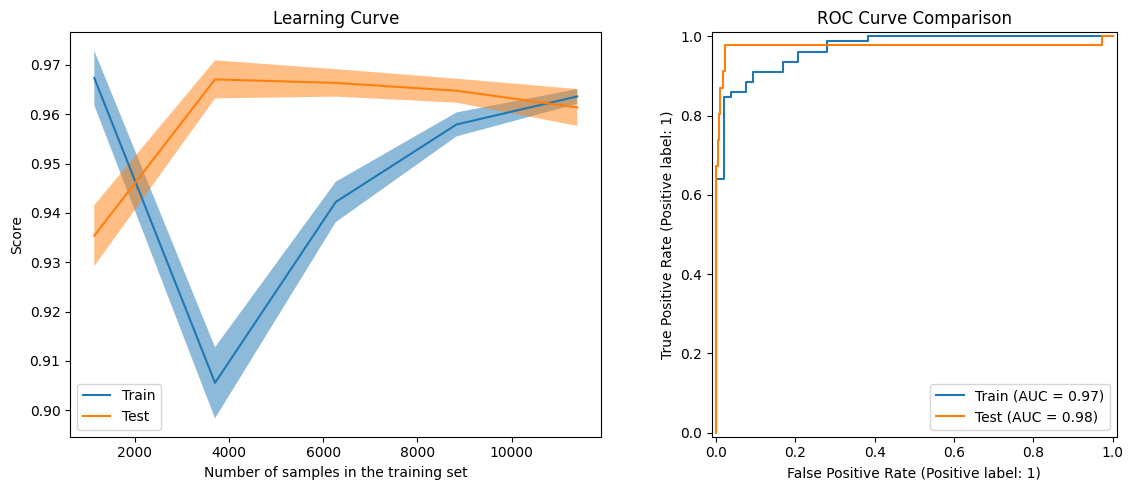

In [196]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold, LearningCurveDisplay, ShuffleSplit
from sklearn.datasets import make_classification
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split

# Perform cross-validation
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot learning curve
LearningCurveDisplay.from_estimator(estimator=hgb, X=X_scaled, y=y, cv=cv, score_type='both', ax = axes[0])
axes[0].set_title("Learning Curve")

# Plot ROC curve
y_test_score = hgb.decision_function(X_test)   
y_train_score = hgb.decision_function(X_train)  
train_disp = RocCurveDisplay.from_predictions(y_train, y_train_score, name = 'Train', ax = axes[1])
test_disp = RocCurveDisplay.from_predictions(y_test, y_test_score, name = 'Test', ax = train_disp.ax_)
axes[1].set_title("ROC Curve Comparison")

plt.tight_layout()
plt.show()

##### GB Classifier
84% accuracy + 92% validation ROC score with 1% train-test gap<br/>
Only works on the initial, smaller dataset and not on the merged dataset with NAs, as GB Classifier does not accept NAs.

In [141]:
from sklearn.ensemble import GradientBoostingClassifier

X_train, X_test = X[:2500], X[2500:]
y_train, y_test = y[:2500], y[2500:]

gb = GradientBoostingClassifier(n_estimators = 200, learning_rate = 0.02, min_samples_leaf = 10, max_depth = 1, subsample = 0.1, max_features = 19, random_state = 0).fit(X_train, y_train)
gb.score(X_test, y_test)
#clf.feature_importances_

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [496]:
from sklearn.metrics import roc_auc_score

auc_weighted = roc_auc_score(y, gb.predict_proba(X)[:, 1])
auc_weighted

np.float64(0.9251447477253928)

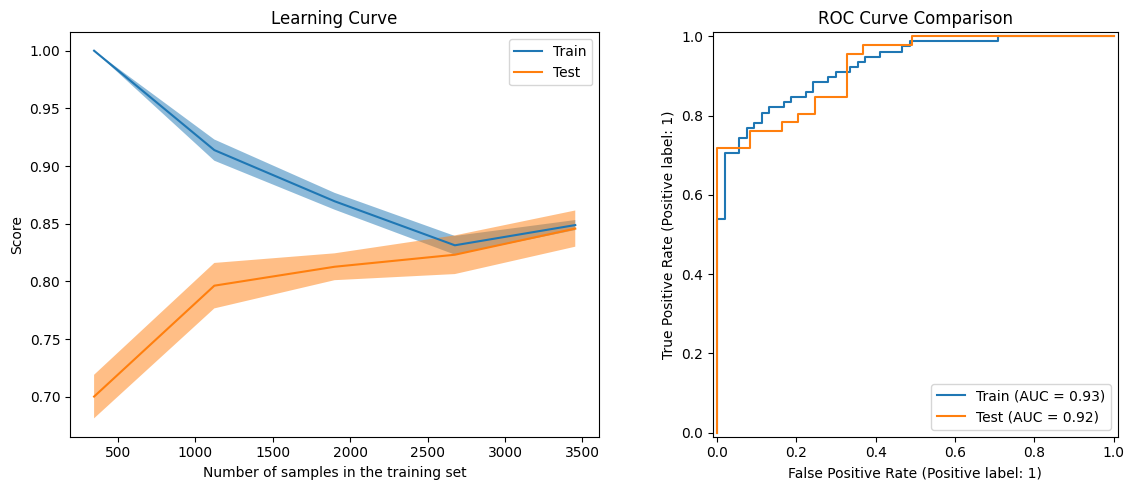

In [499]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit
from sklearn.datasets import make_classification
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split

# Perform cross-validation
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot learning curve
LearningCurveDisplay.from_estimator(estimator = gb, X = X, y = y, cv = cv, score_type='both', ax = axes[0])
axes[0].set_title("Learning Curve")

# Plot ROC curve
y_test_score = gb.decision_function(X_test)   
y_train_score = gb.decision_function(X_train)  
train_disp = RocCurveDisplay.from_predictions(y_train, y_train_score, name = 'Train', ax = axes[1])
test_disp = RocCurveDisplay.from_predictions(y_test, y_test_score, name = 'Test', ax = train_disp.ax_)
axes[1].set_title("ROC Curve Comparison")

plt.tight_layout()
plt.show()

#### Decision Trees
a white box model! 

In [143]:
from sklearn import tree

X_train, X_test = X[:2500], X[2500:]
y_train, y_test = y[:2500], y[2500:]

#clf = tree.DecisionTreeClassifier(max_depth=3, min_samples_split=3, min_samples_leaf=2, max_leaf_nodes=2, max_features=19).fit(X_train, y_train)
clf = tree.DecisionTreeClassifier(splitter='best',
                                  class_weight='balanced',
                                  max_depth=2, 
                                  min_samples_split=15, 
                                  min_samples_leaf=15, 
                                  max_leaf_nodes=5, 
                                  max_features=19, 
                                  ccp_alpha=0.035, 
                                  min_weight_fraction_leaf=0.05, 
                                  random_state=0).fit(X_train, y_train)
clf.score(X_test, y_test)

0.10550142702489912

In [144]:
from sklearn.metrics import roc_auc_score

auc_weighted = roc_auc_score(y, clf.predict_proba(X)[:, 1])
auc_weighted

np.float64(0.6516203377627523)

In [24]:
print(clf.classes_)  # The last entry is the positive class

[0 1]


In [29]:
clf.cost_complexity_pruning_path(X, y)

{'ccp_alphas': array([0.        , 0.01460288, 0.02312981, 0.02739921, 0.0294959 ,
        0.05621532, 0.07432781]),
 'impurities': array([0.24890024, 0.26350311, 0.28663293, 0.31403214, 0.34352804,
        0.39974336, 0.47407117])}

1 = sPTD, therefore, a positive class is preterm birth.

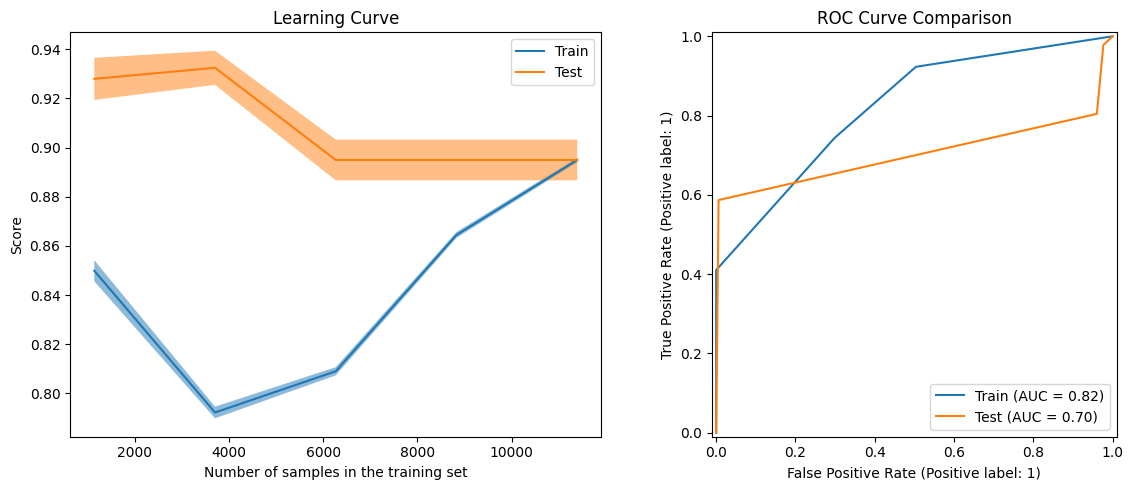

In [145]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold, LearningCurveDisplay, ShuffleSplit
from sklearn.datasets import make_classification
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split

# Perform cross-validation
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot learning curve
LearningCurveDisplay.from_estimator(estimator = clf, X = X, y = y, cv = cv, score_type='both', ax = axes[0])
axes[0].set_title("Learning Curve")

# Plot ROC curve
y_test_score = clf.predict_proba(X_test)[:, 1] # gives the probability of a positive class
y_train_score = clf.predict_proba(X_train)[:, 1]  # gives the probability of a positive class
train_disp = RocCurveDisplay.from_predictions(y_train, y_train_score, name = 'Train', ax = axes[1])
test_disp = RocCurveDisplay.from_predictions(y_test, y_test_score, name = 'Test', ax = train_disp.ax_)
axes[1].set_title("ROC Curve Comparison")

plt.tight_layout()
plt.show()

#### Random Forest
First, smaller dataset (3838): 84.98% accuracy + 91% ROC score on both train and test data<br/>
Second, bigger dataset (12661): 95% accuracy

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test = X_scaled[:3500], X_scaled[3500:] #2.5k was the initial split
y_train, y_test = y[:3500], y[3500:]

rf = RandomForestClassifier(n_estimators=300, 
                            max_depth=3,
                            min_samples_split=20,
                            min_samples_leaf=20,
                            class_weight='balanced',
                            bootstrap=True,
                            ccp_alpha=0.02,
                            random_state=0).fit(X_train, y_train)
scores = cross_val_score(rf, X_test, y_test, cv=5)
scores.mean() # 0.8498211191234837

np.float64(0.9937806873977086)

In [232]:
from sklearn.metrics import roc_auc_score

auc_weighted = roc_auc_score(y, rf.predict_proba(X_scaled)[:, 1])
auc_weighted

np.float64(0.9103480928456277)

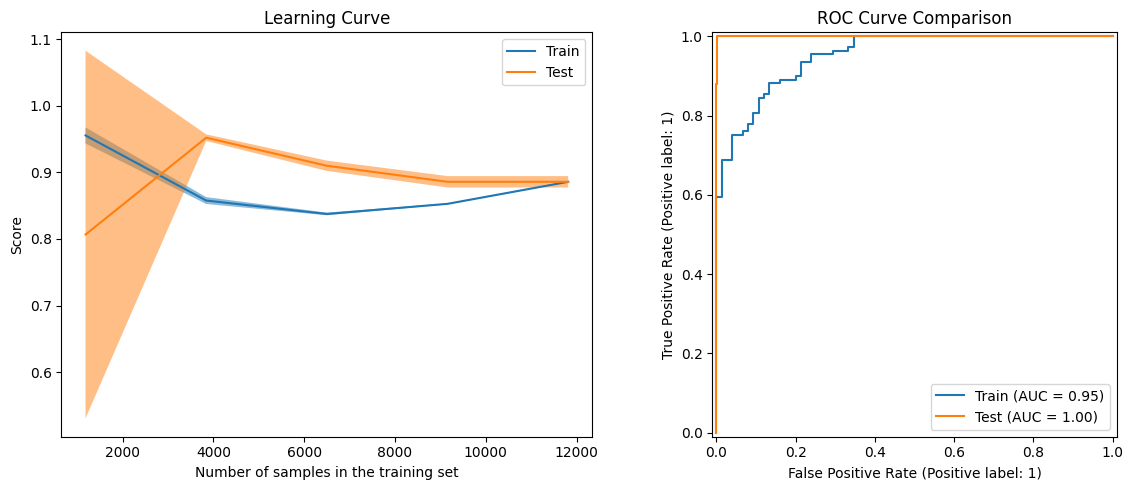

In [233]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedKFold, LearningCurveDisplay, ShuffleSplit
from sklearn.datasets import make_classification
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split

# Perform cross-validation
cv = StratifiedKFold(n_splits = 15, shuffle = True, random_state = 0)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot learning curve
LearningCurveDisplay.from_estimator(estimator = rf, X = X_scaled, y = y, cv = cv, score_type='both', ax = axes[0])
axes[0].set_title("Learning Curve")

# Plot ROC curve
y_test_score = rf.predict_proba(X_test)[:, 1] # gives the probability of a positive class
y_train_score = rf.predict_proba(X_train)[:, 1]  # gives the probability of a positive class
train_disp = RocCurveDisplay.from_predictions(y_train, y_train_score, name = 'Train', ax = axes[1])
test_disp = RocCurveDisplay.from_predictions(y_test, y_test_score, name = 'Test', ax = train_disp.ax_)
axes[1].set_title("ROC Curve Comparison")

plt.tight_layout()
plt.show()

#### Compare RF and HGB Classifiers

In [24]:
# Separate the data into X (features) and y (target)
X = prematurity_model.drop(columns=['Accession', 'Group']).values  # Drop sample ID and target columns
y = prematurity_model['Group'].values                              # the targets are binary
n_samples, n_features = X.shape
print(f"The dataset consists of {n_samples} samples and {n_features} features")

The dataset consists of 3838 samples and 19 features


In [25]:
import joblib

N_CORES = joblib.cpu_count(only_physical_cores=True)
print(f"Number of physical cores: {N_CORES}")

Number of physical cores: 8


In [49]:
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold

models = {
    "Random Forest": RandomForestClassifier(
        min_samples_leaf=5, random_state=0, n_jobs=N_CORES
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_leaf_nodes=15, random_state=0, early_stopping=False
    ),
}
param_grids = {
    "Random Forest": {"n_estimators": [10, 20, 50, 100]},
    "Hist Gradient Boosting": {"max_iter": [10, 20, 50, 100, 300, 500]},
}
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)

results = []
for name, model in models.items():
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        return_train_score=True,
        cv=cv,
    ).fit(X, y)
    result = {"model": name, "cv_results": pd.DataFrame(grid_search.cv_results_)}
    results.append(result)

In [50]:
import plotly.colors as colors
import plotly.express as px
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1,
    cols=2,
    shared_yaxes=True,
    subplot_titles=["Train time vs score", "Predict time vs score"],
)
model_names = [result["model"] for result in results]
colors_list = colors.qualitative.Plotly * (
    len(model_names) // len(colors.qualitative.Plotly) + 1
)

for idx, result in enumerate(results):
    cv_results = result["cv_results"].round(3)
    model_name = result["model"]
    param_name = next(iter(param_grids[model_name].keys()))
    cv_results[param_name] = cv_results["param_" + param_name]
    cv_results["model"] = model_name

    scatter_fig = px.scatter(
        cv_results,
        x="mean_fit_time",
        y="mean_test_score",
        error_x="std_fit_time",
        error_y="std_test_score",
        hover_data=param_name,
        color="model",
    )
    line_fig = px.line(
        cv_results,
        x="mean_fit_time",
        y="mean_test_score",
    )

    scatter_trace = scatter_fig["data"][0]
    line_trace = line_fig["data"][0]
    scatter_trace.update(marker=dict(color=colors_list[idx]))
    line_trace.update(line=dict(color=colors_list[idx]))
    fig.add_trace(scatter_trace, row=1, col=1)
    fig.add_trace(line_trace, row=1, col=1)

    scatter_fig = px.scatter(
        cv_results,
        x="mean_score_time",
        y="mean_test_score",
        error_x="std_score_time",
        error_y="std_test_score",
        hover_data=param_name,
    )
    line_fig = px.line(
        cv_results,
        x="mean_score_time",
        y="mean_test_score",
    )

    scatter_trace = scatter_fig["data"][0]
    line_trace = line_fig["data"][0]
    scatter_trace.update(marker=dict(color=colors_list[idx]))
    line_trace.update(line=dict(color=colors_list[idx]))
    fig.add_trace(scatter_trace, row=1, col=2)
    fig.add_trace(line_trace, row=1, col=2)

fig.update_layout(
    xaxis=dict(title="Train time (s) - lower is better"),
    yaxis=dict(title="Test R2 score - higher is better"),
    xaxis2=dict(title="Predict time (s) - lower is better"),
    legend=dict(x=0.72, y=0.05, traceorder="normal", borderwidth=1),
    title=dict(x=0.5, text="Speed-score trade-off of tree-based ensembles"),
)

Below is the old work, above is the work from scikit learn documentation.

In [52]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Step 1: Feature Selection 
selector = SelectKBest(score_func=f_classif, k = 19)  
X_selected = selector.fit_transform(X, y)

# Step 2: Standardize selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Step 3: Configure anti-overfitting Random Forest
rf_final = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    max_samples=0.5,
    class_weight='balanced',
    random_state=42,
    oob_score=True
)

# Step 4: Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Step 5: Comprehensive evaluation
metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
for metric in metrics:
    scores = cross_val_score(rf_final, X_scaled, y, cv=skf, scoring=metric)
    print(f"{metric.lower():20}: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

# Step 6: Train final model and check OOB score
rf_final.fit(X_scaled, y)
print(f"\nOut-of-Bag Score: {rf_final.oob_score_:.3f}")

# Step 7: Learning curve analysis
train_sizes, train_scores, val_scores = learning_curve(
    rf_final, X_scaled, y, cv=skf, train_sizes=np.linspace(0.2, 1.0, 5)
)
print(f"Training Score (final): {train_scores.mean(axis=1)[-1]:.3f}")
print(f"Validation Score (final): {val_scores.mean(axis=1)[-1]:.3f}")
print(f"Overfitting Gap: {train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]:.3f}")

accuracy            : 0.979 (+/- 0.017)
precision_weighted  : 0.980 (+/- 0.017)
recall_weighted     : 0.979 (+/- 0.017)
f1_weighted         : 0.979 (+/- 0.017)

Out-of-Bag Score: 0.993
Training Score (final): 0.984
Validation Score (final): 0.979
Overfitting Gap: 0.005


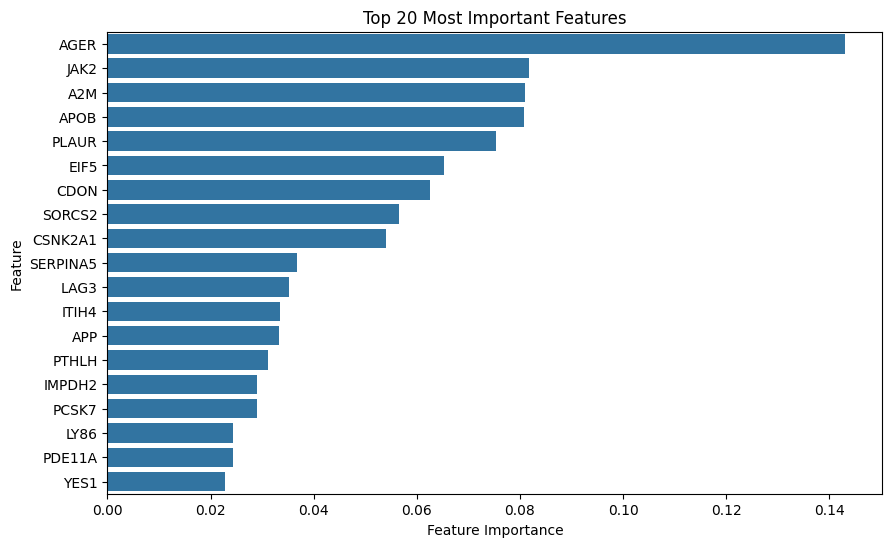

In [53]:
# Assess feature importance
features = prematurity_model.columns[2:].tolist() # Select all columns except the first two
features

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]  # Sort in descending order

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices][:20], y=np.array(features)[indices][:20])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features")
plt.show()

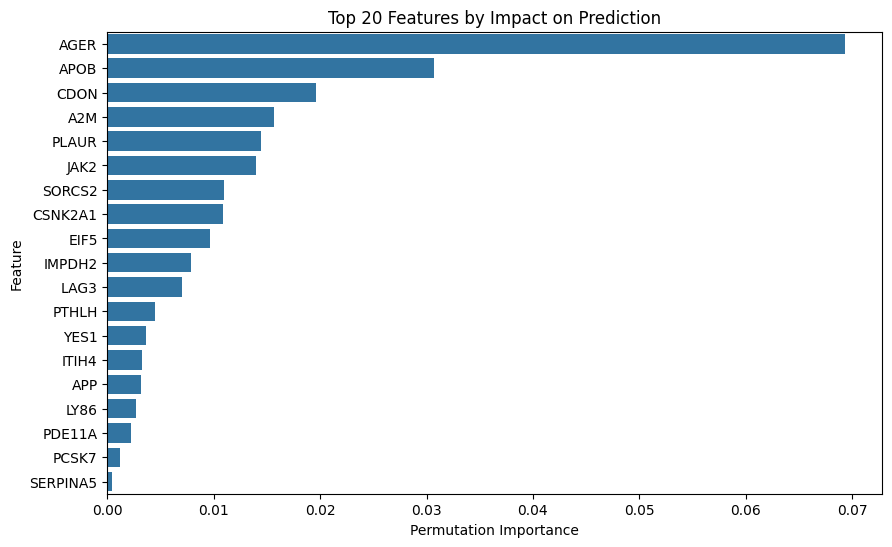

In [54]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf_final, X_scaled, y, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=result.importances_mean[sorted_idx][:20], y=np.array(features)[sorted_idx][:20])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Impact on Prediction")
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

auc_weighted = roc_auc_score(y, rf_final.predict_proba(X)[:, 1])
auc_weighted

##### Explain the model using SHAP
>SHAP (SHapley Additive exPlanations) offers the most rigorous mathematical foundation for explainability, based on cooperative game theory. SHAP values satisfy efficiency, symmetry, dummy, and additivity axioms, providing theoretically grounded explanations for individual predictions. (Claude, 2025)

In [66]:
import shap

In [80]:
feature_names = prematurity_model.drop(columns=['Accession', 'Group'])
feature_names = list(feature_names.columns)
feature_names

['A2M',
 'AGER',
 'APOB',
 'APP',
 'CDON',
 'CSNK2A1',
 'EIF5',
 'IMPDH2',
 'ITIH4',
 'JAK2',
 'LAG3',
 'LY86',
 'PCSK7',
 'PDE11A',
 'PLAUR',
 'PTHLH',
 'SERPINA5',
 'SORCS2',
 'YES1']

362it [00:20,  7.57it/s]                         


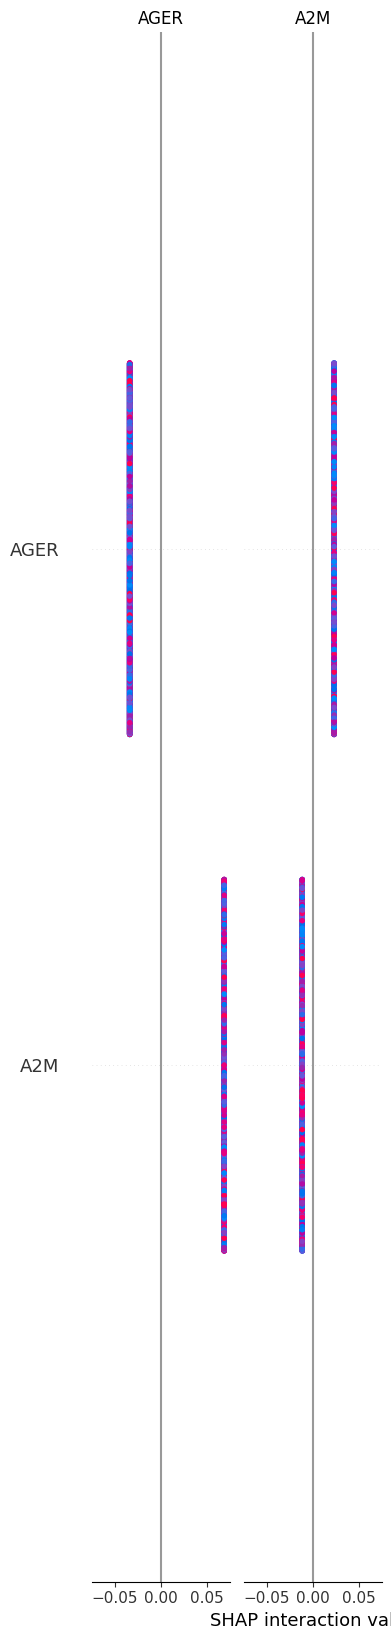

In [86]:
explainer = shap.Explainer(rf_final)
shap_values = explainer(X)

clust = shap.utils.hclust(X, y, linkage="single")
#shap.summary_plot(shap_values, X, feature_names=feature_names, plot_type='bar')
shap.summary_plot(shap_values, X, feature_names=feature_names, max_display=19)

In [90]:
type(shap_interaction_values)
# If it's a list, print the shape of each element:
if isinstance(shap_interaction_values, list):
    print([arr.shape for arr in shap_interaction_values])
else:
    print(shap_interaction_values.shape)

(3838, 19, 19, 2)


AssertionError: Feature and SHAP matrices must have the same number of rows!

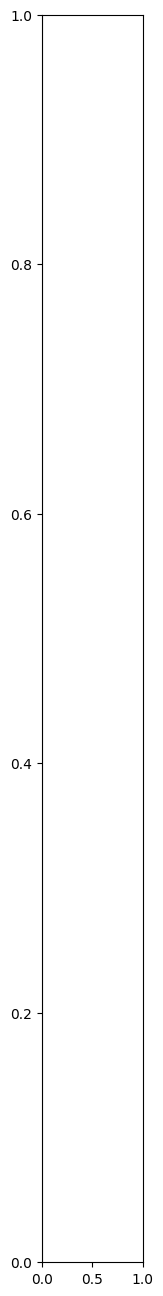

In [94]:
shap_interaction_values = explainer.shap_interaction_values(X)
shap.summary_plot(shap_interaction_values[3], X, feature_names=feature_names, max_display=19)

In [78]:
print(type(shap_values))
print(getattr(shap_values, 'shape', None))

<class 'shap._explanation.Explanation'>
(3838, 19, 2)


#### Model predicting gestational age